# LIBRARIES

In [386]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from statistics import mode
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OrdinalEncoder
from sklearn.feature_selection import mutual_info_classif


import tensorflow as tf
import time


import torch
import torch.nn as nn
import torch.optim as optim


#READING THE DATA

In [387]:
filepath = '/content/drive/MyDrive/ICT AIML/Datasets/adult_dataset.csv'
df_adult = pd.read_csv(filepath)
df_adult.head(2)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K


#EDA

In [388]:
df_adult.shape

(48842, 15)

In [389]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [390]:
df_adult.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [391]:
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df_adult[col].value_counts())


Column: workclass
workclass
Private             32220
Self-emp-not-inc     3649
Local-gov            2973
State-gov            1877
?                    1763
Self-emp-inc         1625
Federal-gov          1346
Without-pay            18
Never-worked            9
Name: count, dtype: int64

Column: education
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

Column: marital-status
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

Column: occupation
oc

In [392]:
df_adult['education-num'].value_counts()

,count
education-num,
9,15784
10,10878
13,8025
14,2657
11,2061
7,1812
12,1601
6,1389
4,955


In [393]:
# INFERENCE
#--------------
# native_country has dominated US population so we cant really identify a pattern using this column drop naive_country
# race is dominated with white so here also we cant really identify any pattern drop race
# Both education and education-num represents the same  data so no need to keep both drop education

In [394]:
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df_adult[col].nunique())


Column: workclass
9

Column: education
16

Column: marital-status
7

Column: occupation
15

Column: relationship
6

Column: race
5

Column: sex
2

Column: native-country
42

Column: income
4


In [395]:
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df_adult[col].unique())


Column: workclass
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' nan 'Local-gov'
 '?' 'Self-emp-inc' 'Without-pay' 'Never-worked']

Column: education
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

Column: marital-status
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

Column: occupation
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' nan
 'Protective-serv' '?' 'Armed-Forces' 'Priv-house-serv']

Column: relationship
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']

Column: race
['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']

Column: sex
['Male' 'Female']

Column: native-country
[nan 'United-States' 'Cuba' 

In [396]:
# ? present replace that
# Income column has no logic

## PLOT

In [397]:
num_cols = df_adult.select_dtypes(include=['int','float']).columns
cat_cols = df_adult.select_dtypes(include=['object','bool']).columns


In [398]:
print("Numerical Columns ",num_cols)
print("Categorical ",cat_cols)

Numerical Columns  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
Categorical  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')


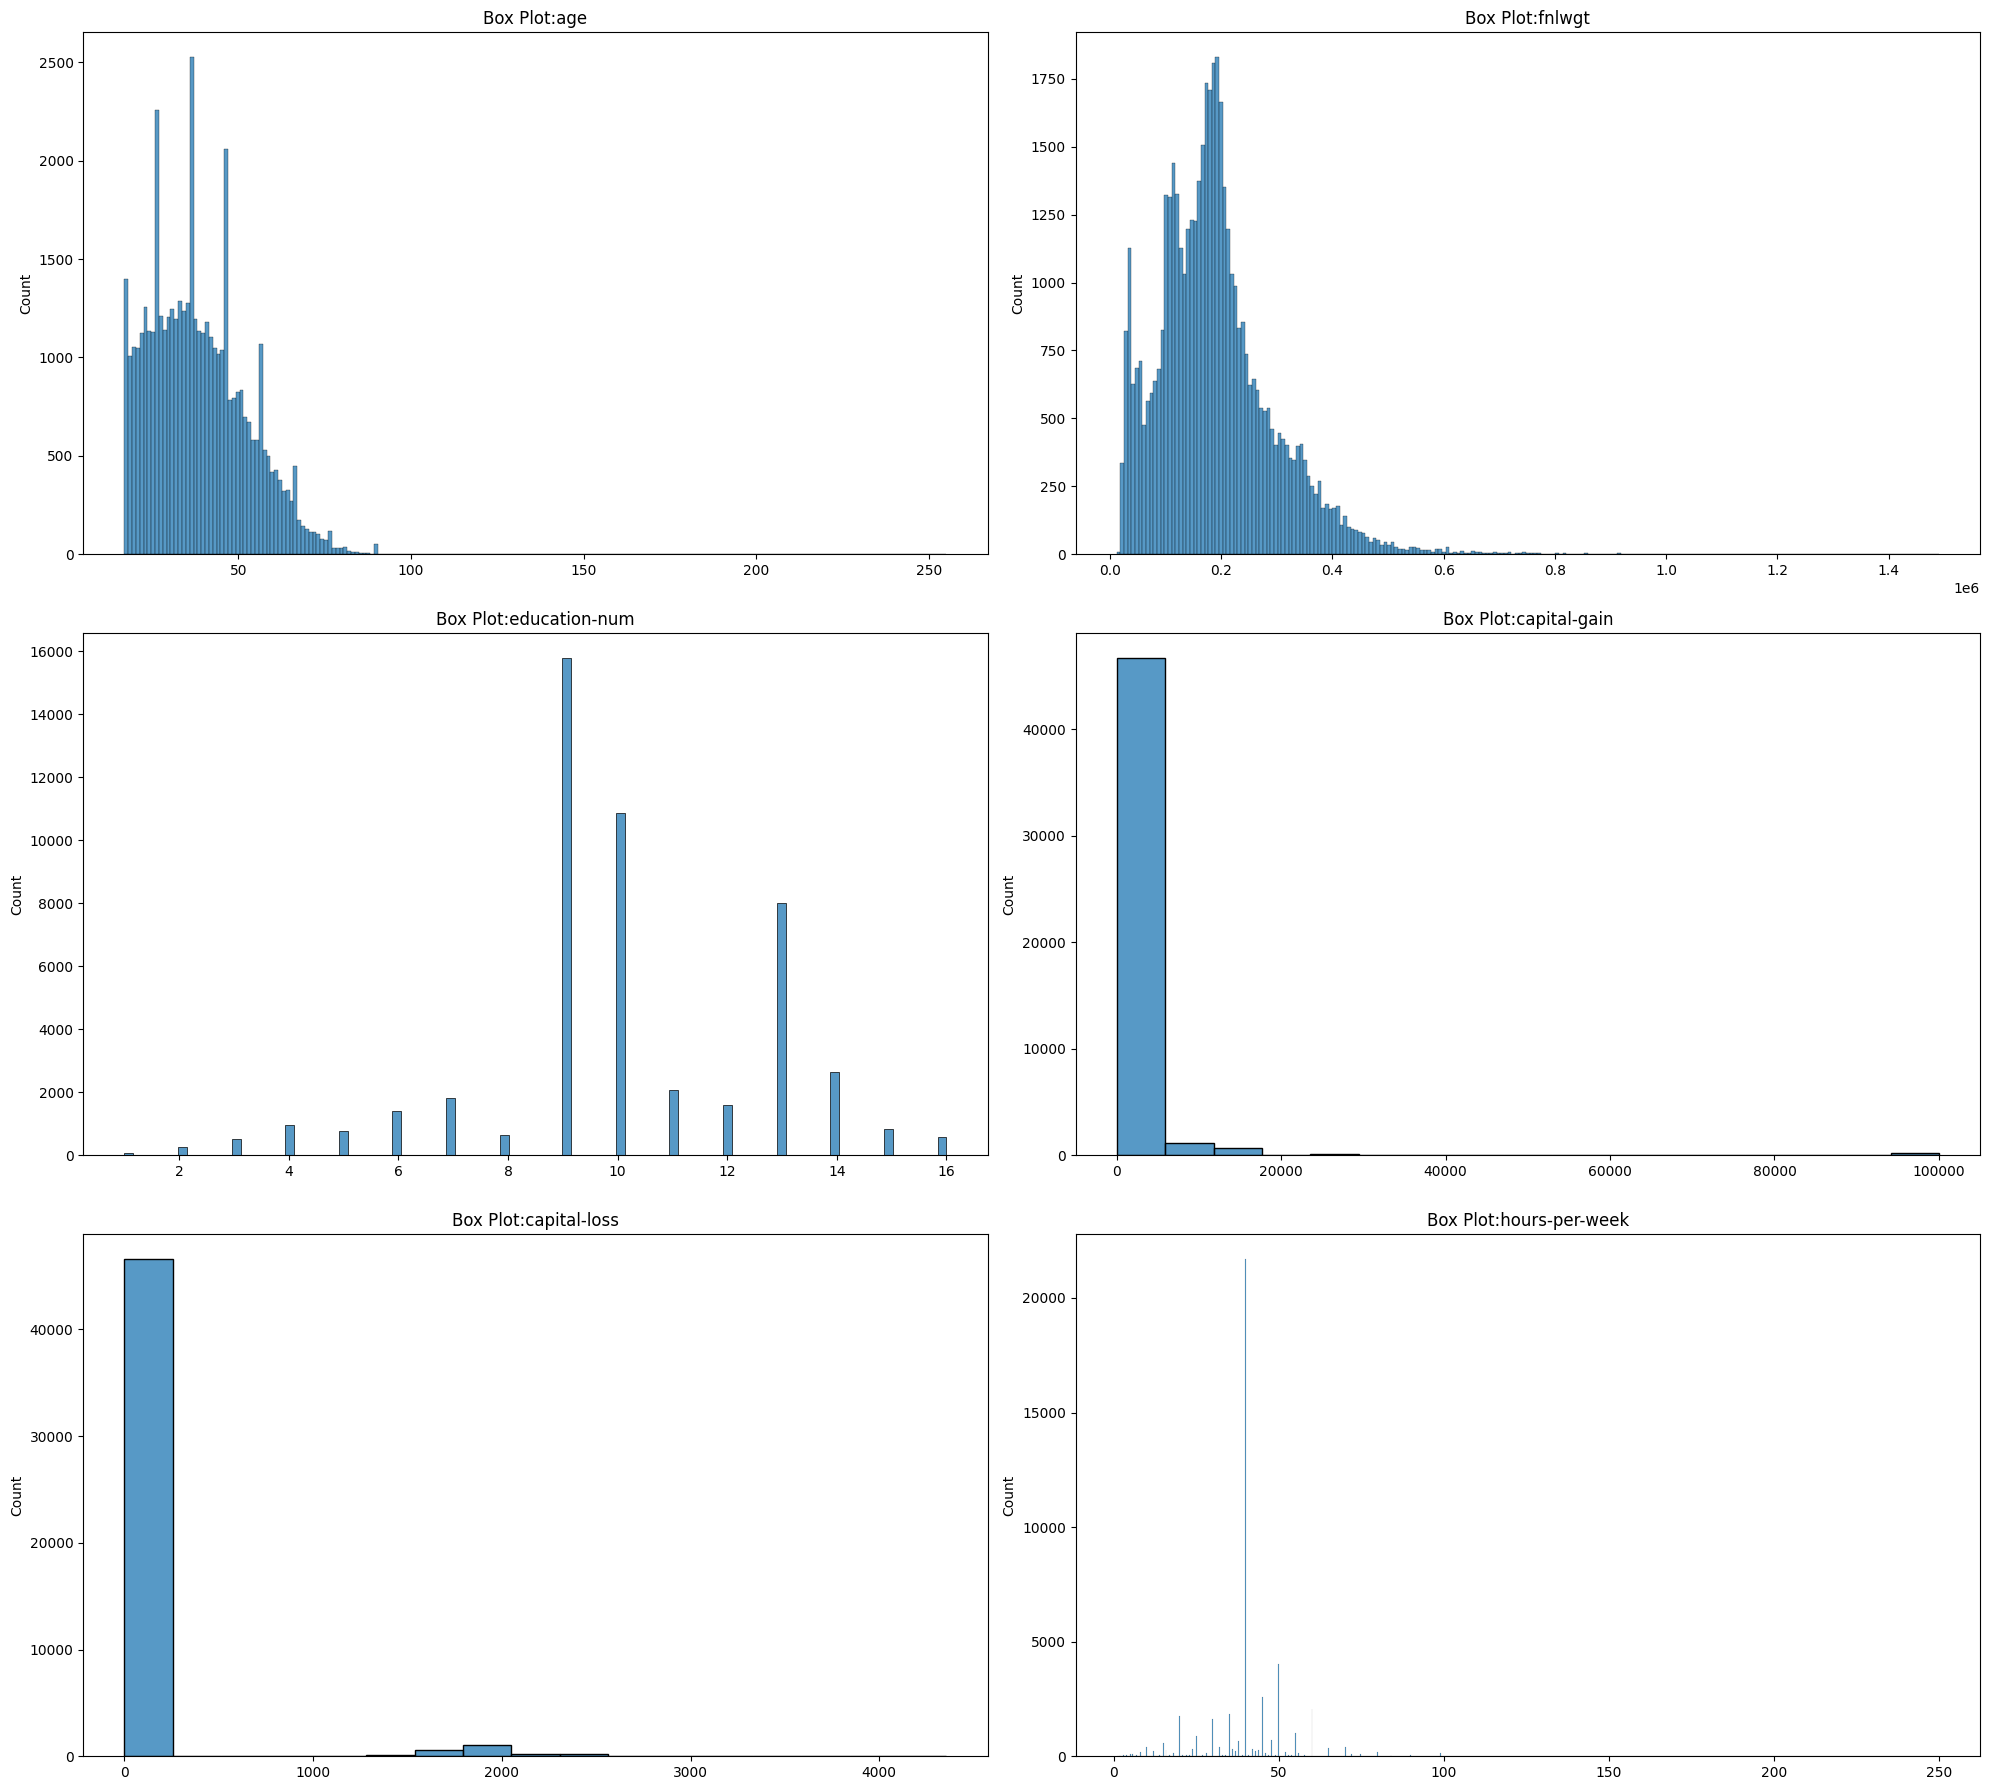

In [399]:
plt.figure(figsize=(20,18))

for i,col in enumerate(num_cols):
  plt.subplot(3,2,i+1)
  sns.histplot(df_adult[col])
  plt.title(f'Box Plot:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

In [400]:
# All are skewed values

# CORRELATION MATRIX

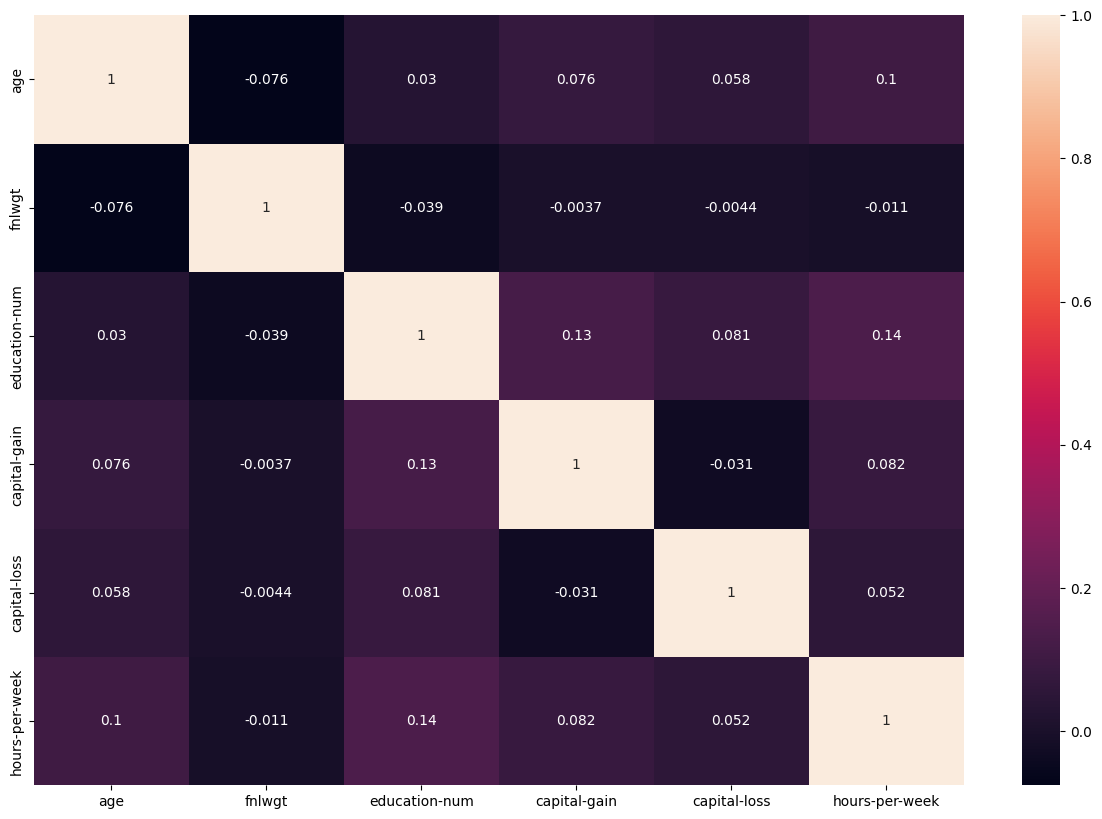

In [401]:

corr_mat = df_adult[num_cols].corr()
plt.figure(figsize = (15,10))
sns.heatmap(corr_mat,annot = True)
plt.show()

# DATA PREPROCESSING

## DATA CLEANING

### MISSING VALUE  HANDLING

In [402]:
df_adult.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [403]:
df_adult['age'].fillna(df_adult['age'].median(),inplace = True)

/tmp/ipykernel_781/1097525711.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_adult['age'].fillna(df_adult['age'].median(),inplace = True)


In [404]:
df_adult['workclass'].replace('?', mode(df_adult['workclass']),inplace = True)



/tmp/ipykernel_781/340647654.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_adult['workclass'].replace('?', mode(df_adult['workclass']),inplace = True)


In [405]:
df_adult['workclass'].fillna (mode(df_adult['workclass']),inplace = True)

/tmp/ipykernel_781/3281242043.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_adult['workclass'].fillna (mode(df_adult['workclass']),inplace = True)


In [406]:
df_adult['occupation'].replace('?', mode(df_adult['occupation']),inplace = True)

df_adult['occupation'].fillna(mode(df_adult['occupation']),inplace = True)

/tmp/ipykernel_781/4274046948.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_adult['occupation'].replace('?', mode(df_adult['occupation']),inplace = True)
/tmp/ipykernel_781/4274046948.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

In [407]:
df_adult['hours-per-week'].fillna(df_adult['hours-per-week'].median(),inplace = True)

/tmp/ipykernel_781/3406498704.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_adult['hours-per-week'].fillna(df_adult['hours-per-week'].median(),inplace = True)


In [408]:
# Drop unneccessary columns
df_adult.drop(columns = ['native-country','education','race','fnlwgt'],inplace = True)

In [409]:
df_adult.isna().sum()

,0
age,0
workclass,0
education-num,0
marital-status,0
occupation,0
relationship,0
sex,0
capital-gain,0
capital-loss,0
hours-per-week,0


### OUTLIER HANDLING

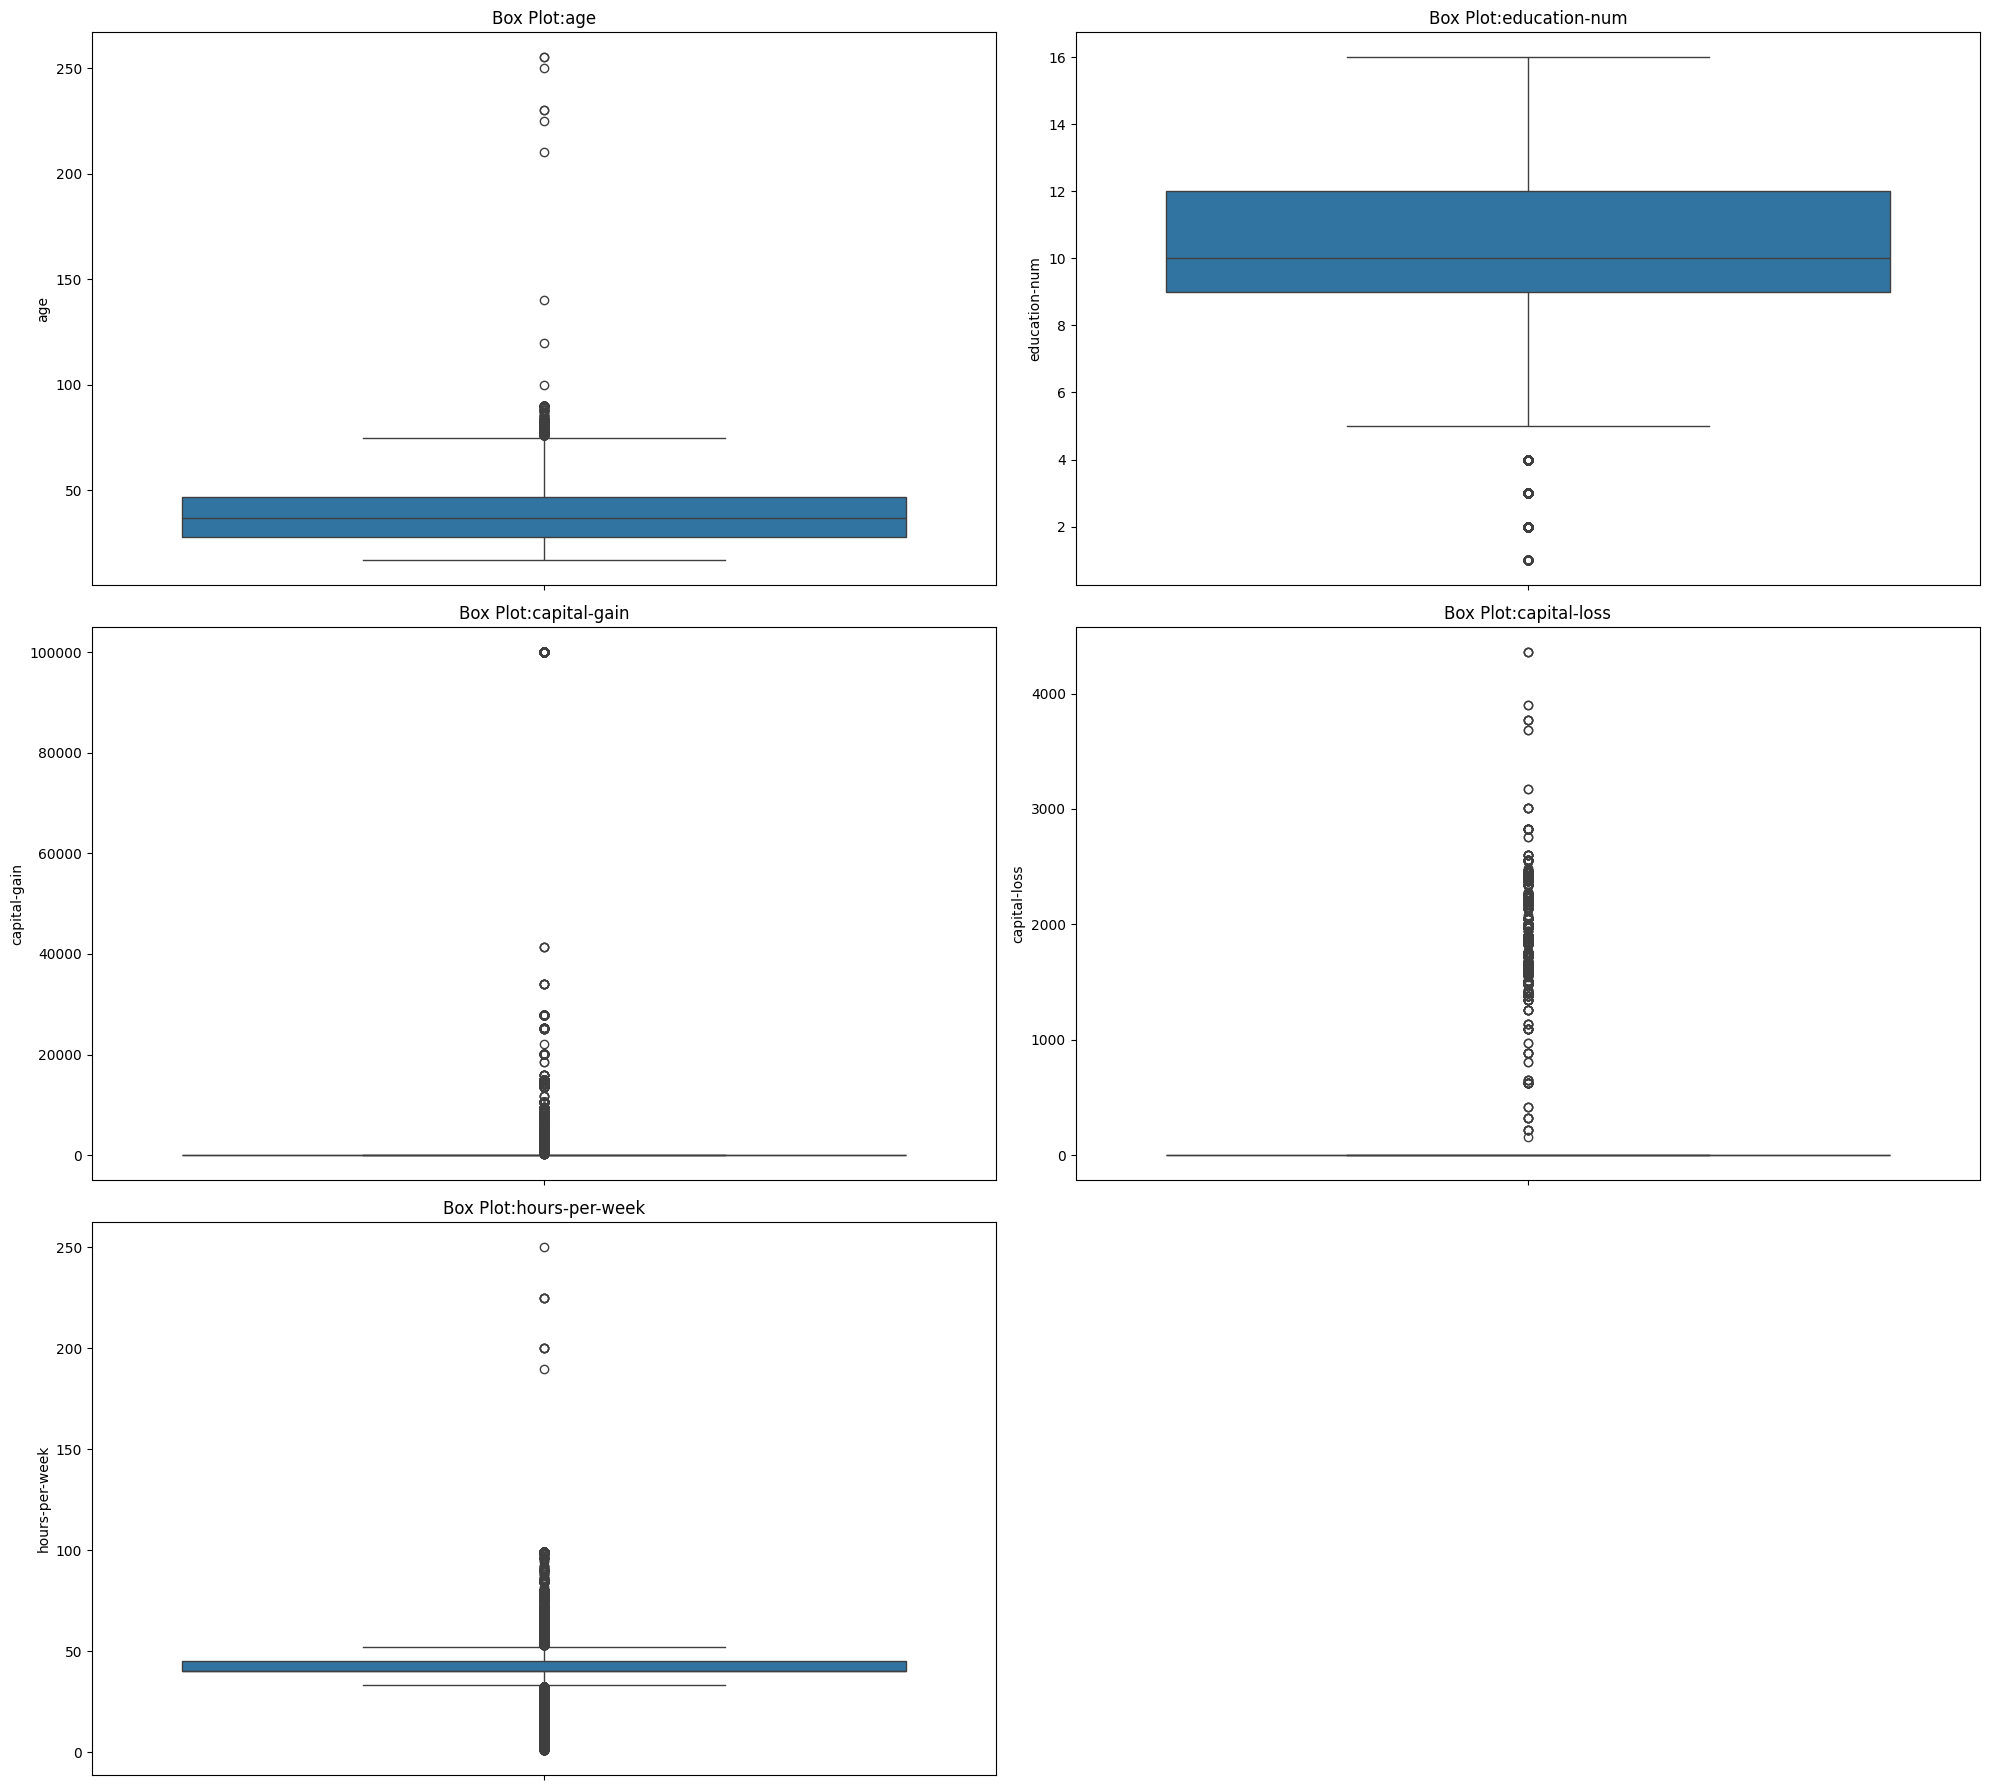

In [410]:
#outlier Detection
num_cols = df_adult.select_dtypes(include = ['int64','float64']).columns
plt.figure(figsize=(20,18))

for i,col in enumerate(num_cols):
  plt.subplot(3,2,i+1)
  sns.boxplot(df_adult[col])
  plt.title(f'Box Plot:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

In [411]:
outlier_cols = ['age','education-num','capital-gain','capital-loss','hours-per-week']

for i in outlier_cols:
  Q1 = df_adult[i].quantile(0.25)
  Q3 = df_adult[i].quantile(0.75)

  IQR = Q3-Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df_adult[(df_adult[i] < lower_bound) | (df_adult[i] > upper_bound ) ]
  print(f"{i} : {len(outliers)} outliers")
  df_adult[i] = df_adult[i].clip(lower = lower_bound, upper = upper_bound)


age : 364 outliers
education-num : 1794 outliers
capital-gain : 4035 outliers
capital-loss : 2282 outliers
hours-per-week : 12838 outliers


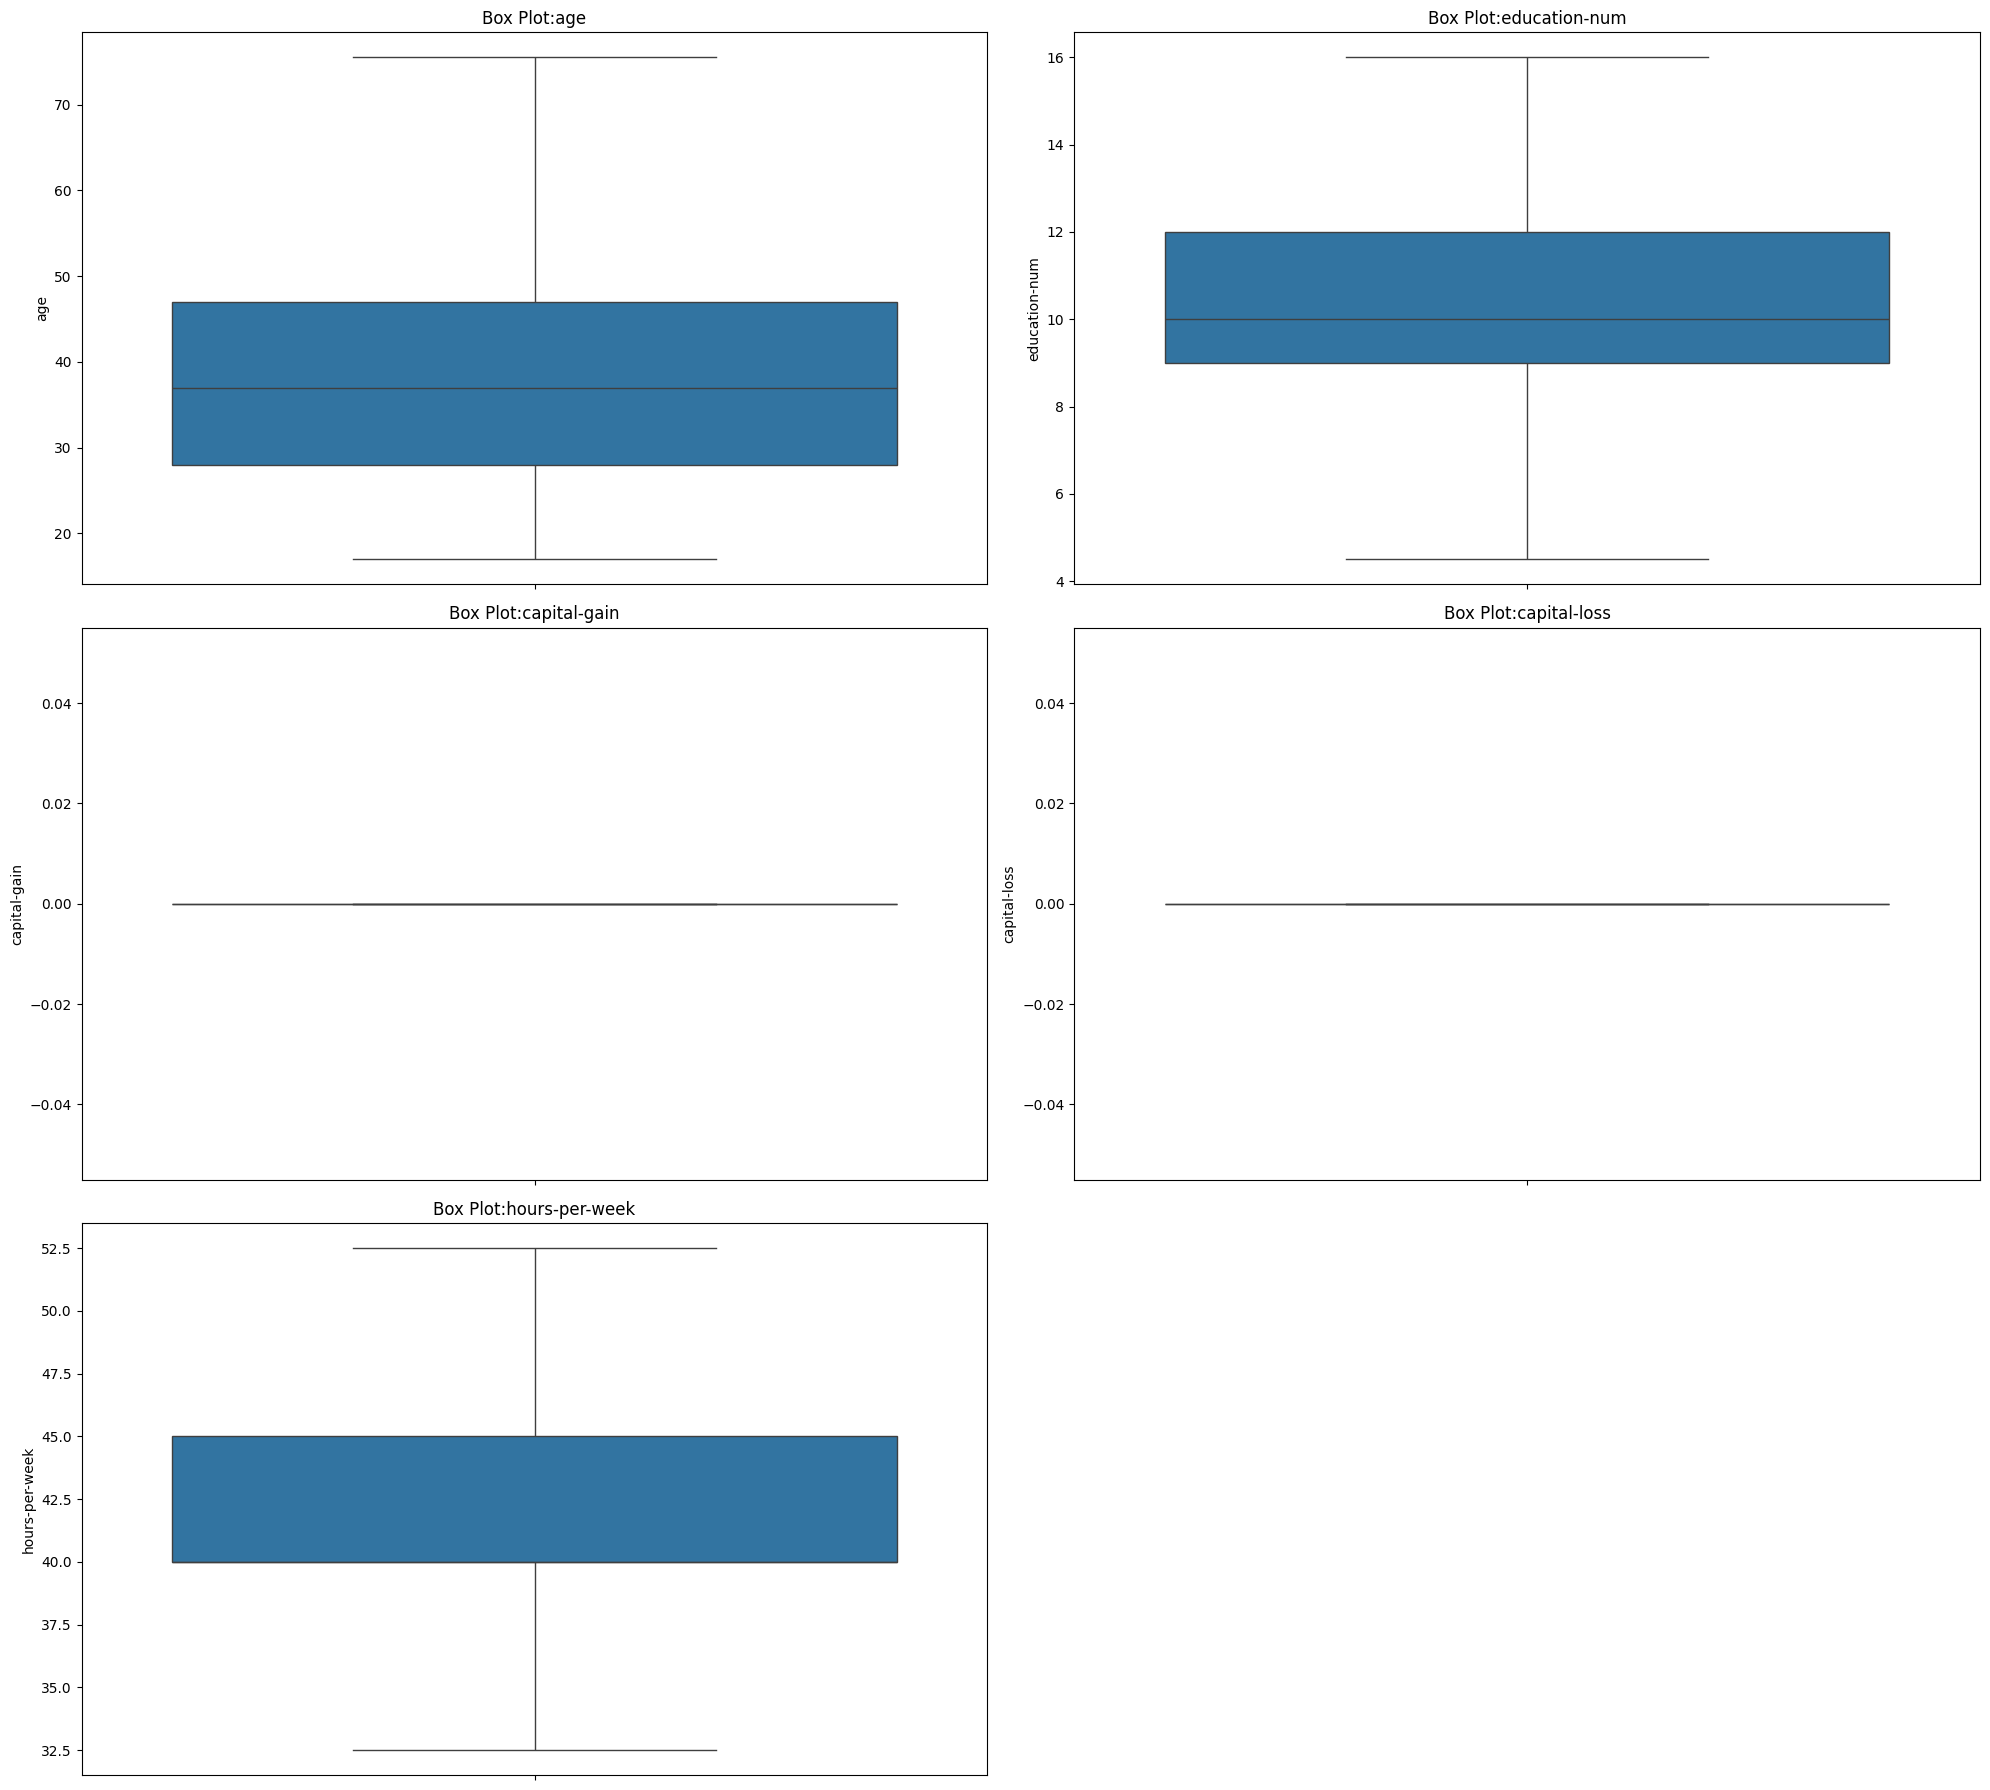

In [412]:
# After Outlier Handling
plt.figure(figsize=(20,18))

for i,col in enumerate(num_cols):
  plt.subplot(3,2,i+1)
  sns.boxplot(df_adult[col])
  plt.title(f'Box Plot:{col}')

plt.tight_layout()
plt.show()

### DUPLICATE REMOVAL

In [413]:
df_adult.duplicated().sum()

np.int64(9634)

In [414]:
df_adult.drop_duplicates(inplace = True)

In [415]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39208 entries, 0 to 48841
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             39208 non-null  float64
 1   workclass       39208 non-null  object 
 2   education-num   39208 non-null  float64
 3   marital-status  39208 non-null  object 
 4   occupation      39208 non-null  object 
 5   relationship    39208 non-null  object 
 6   sex             39208 non-null  object 
 7   capital-gain    39208 non-null  int64  
 8   capital-loss    39208 non-null  int64  
 9   hours-per-week  39208 non-null  float64
 10  income          39208 non-null  object 
dtypes: float64(3), int64(2), object(6)
memory usage: 3.6+ MB


In [416]:
df_adult.shape

(39208, 11)

# DATA TRANSFORMATIONS

##ENCODING

In [417]:
cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

In [418]:
df_adult['income'].unique()

array(['<=50K', '>50K', '<=50K.', '>50K.'], dtype=object)

In [419]:
# Foramtting income column to 2 outputs
df_adult['income'] = df_adult['income'].str.replace('.', '', regex=False)
df_adult['income'].unique()

array(['<=50K', '>50K'], dtype=object)

###LABEL ENCODING

In [420]:
# Before encoding
df_adult.head()

,age,workclass,education-num,marital-status,occupation,relationship,sex,capital-gain,capital-loss,hours-per-week,income
0,39.0,State-gov,13.0,Never-married,Adm-clerical,Not-in-family,Male,0,0,40.0,<=50K
1,50.0,Self-emp-not-inc,13.0,Married-civ-spouse,Exec-managerial,Husband,Male,0,0,32.5,<=50K
2,38.0,Private,9.0,Divorced,Handlers-cleaners,Not-in-family,Male,0,0,40.0,<=50K
3,53.0,Private,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Male,0,0,40.0,<=50K
4,28.0,Private,13.0,Married-civ-spouse,Prof-specialty,Wife,Female,0,0,40.0,<=50K


In [421]:
label_enc = LabelEncoder()

df_adult['income'] = label_enc.fit_transform(df_adult['income'])    # target column
df_adult['sex'] = label_enc.fit_transform(df_adult['sex'])          # sex has binary class data

In [422]:
# After encoding
df_adult.head()

,age,workclass,education-num,marital-status,occupation,relationship,sex,capital-gain,capital-loss,hours-per-week,income
0,39.0,State-gov,13.0,Never-married,Adm-clerical,Not-in-family,1,0,0,40.0,0
1,50.0,Self-emp-not-inc,13.0,Married-civ-spouse,Exec-managerial,Husband,1,0,0,32.5,0
2,38.0,Private,9.0,Divorced,Handlers-cleaners,Not-in-family,1,0,0,40.0,0
3,53.0,Private,7.0,Married-civ-spouse,Handlers-cleaners,Husband,1,0,0,40.0,0
4,28.0,Private,13.0,Married-civ-spouse,Prof-specialty,Wife,0,0,0,40.0,0


##ONE HOT ENCODING

In [423]:
df_adult['marital-status'].unique()

array(['Never-married', 'Married-civ-spouse', 'Divorced',
       'Married-spouse-absent', 'Separated', 'Married-AF-spouse',
       'Widowed'], dtype=object)

In [424]:
df_adult['occupation'].unique()

array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

In [425]:
df_adult['relationship'].unique()


array(['Not-in-family', 'Husband', 'Wife', 'Own-child', 'Unmarried',
       'Other-relative'], dtype=object)

In [426]:
df_adult['workclass'].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [427]:
# Before encoding
df_adult.head()

,age,workclass,education-num,marital-status,occupation,relationship,sex,capital-gain,capital-loss,hours-per-week,income
0,39.0,State-gov,13.0,Never-married,Adm-clerical,Not-in-family,1,0,0,40.0,0
1,50.0,Self-emp-not-inc,13.0,Married-civ-spouse,Exec-managerial,Husband,1,0,0,32.5,0
2,38.0,Private,9.0,Divorced,Handlers-cleaners,Not-in-family,1,0,0,40.0,0
3,53.0,Private,7.0,Married-civ-spouse,Handlers-cleaners,Husband,1,0,0,40.0,0
4,28.0,Private,13.0,Married-civ-spouse,Prof-specialty,Wife,0,0,0,40.0,0


In [428]:
df_adult = pd.get_dummies(df_adult, columns=['marital-status','occupation','relationship','workclass'], drop_first=True)


In [429]:
# After encoding
df_adult.head()

,age,education-num,sex,capital-gain,capital-loss,hours-per-week,income,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,...,relationship_Own-child,relationship_Unmarried,relationship_Wife,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
0,39.0,13.0,1,0,0,40.0,0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,50.0,13.0,1,0,0,32.5,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,38.0,9.0,1,0,0,40.0,0,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,53.0,7.0,1,0,0,40.0,0,False,True,False,...,False,False,False,False,False,True,False,False,False,False
4,28.0,13.0,0,0,0,40.0,0,False,True,False,...,False,False,True,False,False,True,False,False,False,False


In [430]:
df_adult.shape

(39208, 38)

## DATA SPLITTING

In [431]:
y = df_adult['income']
X = df_adult.drop('income' , axis =1)
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.2)

##SCALING

### MINMAX SCALING

In [432]:
skewed_cols = ['age','education-num','capital-gain','capital-loss','hours-per-week']
skewed_cols

['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

In [433]:
# Before scaling
df_adult.head()

,age,education-num,sex,capital-gain,capital-loss,hours-per-week,income,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,...,relationship_Own-child,relationship_Unmarried,relationship_Wife,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
0,39.0,13.0,1,0,0,40.0,0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,50.0,13.0,1,0,0,32.5,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,38.0,9.0,1,0,0,40.0,0,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,53.0,7.0,1,0,0,40.0,0,False,True,False,...,False,False,False,False,False,True,False,False,False,False
4,28.0,13.0,0,0,0,40.0,0,False,True,False,...,False,False,True,False,False,True,False,False,False,False


In [434]:
minmax_scaler = MinMaxScaler()


In [435]:
X_train[skewed_cols] = minmax_scaler.fit_transform(X_train[skewed_cols])
X_test[skewed_cols] = minmax_scaler.transform(X_test[skewed_cols])

In [436]:
#After scaling
df_adult.head()

,age,education-num,sex,capital-gain,capital-loss,hours-per-week,income,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,...,relationship_Own-child,relationship_Unmarried,relationship_Wife,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
0,39.0,13.0,1,0,0,40.0,0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,50.0,13.0,1,0,0,32.5,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,38.0,9.0,1,0,0,40.0,0,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,53.0,7.0,1,0,0,40.0,0,False,True,False,...,False,False,False,False,False,True,False,False,False,False
4,28.0,13.0,0,0,0,40.0,0,False,True,False,...,False,False,True,False,False,True,False,False,False,False


In [437]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39208 entries, 0 to 48841
Data columns (total 38 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   39208 non-null  float64
 1   education-num                         39208 non-null  float64
 2   sex                                   39208 non-null  int64  
 3   capital-gain                          39208 non-null  int64  
 4   capital-loss                          39208 non-null  int64  
 5   hours-per-week                        39208 non-null  float64
 6   income                                39208 non-null  int64  
 7   marital-status_Married-AF-spouse      39208 non-null  bool   
 8   marital-status_Married-civ-spouse     39208 non-null  bool   
 9   marital-status_Married-spouse-absent  39208 non-null  bool   
 10  marital-status_Never-married          39208 non-null  bool   
 11  marital-status_Separ

# MODEL BUILDING - TENSORFLOW

In [438]:
print(X_train.shape)
print(y_train.shape)

(31366, 37)
(31366,)


In [439]:
model = tf.keras.Sequential([                                               # 30 -input layer
    tf.keras.layers.Dense(64, activation = 'relu', input_shape= (37,)),     # 64 -first hidden layer
    tf.keras.layers.Dense(32, activation = 'relu'),                         # 32 -second hidden layer
    tf.keras.layers.Dense(1, activation = 'sigmoid')                        # 1 - output layer
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [440]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [441]:
start_time = time.perf_counter()

history = model.fit( X_train,
                    y_train,
                     epochs = 50,
                     batch_size = 32,
                     validation_split = 0.2,
                     verbose = 1
                     )

end_time = time.perf_counter()
print(f"Training time: {end_time - start_time:0.4f} seconds")

Epoch 1/50
785/785 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8079 - loss: 0.4051 - val_accuracy: 0.8164 - val_loss: 0.3827
Epoch 2/50
785/785 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8209 - loss: 0.3738 - val_accuracy: 0.8196 - val_loss: 0.3762
Epoch 3/50
785/785 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8223 - loss: 0.3705 - val_accuracy: 0.8234 - val_loss: 0.3730
Epoch 4/50
785/785 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8225 - loss: 0.3683 - val_accuracy: 0.8221 - val_loss: 0.3715
Epoch 5/50
785/785 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8250 - loss: 0.3658 - val_accuracy: 0.8223 - val_loss: 0.3690
Epoch 6/50
785/785 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8260 - loss: 0.3638 - val_accuracy: 0.8208 - val_loss: 0.3687
Epoch 7/50
785/785 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8251 - loss: 0.3619 - val_accuracy: 0.8212 - val_loss: 0.3691
Epoch 8/50
785/785 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8269 - loss: 0.3609 - val_accuracy: 0.

In [442]:
loss, accuracy = model.evaluate(X_test,y_test)
print("Accuracy",accuracy)

246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8252 - loss: 0.3754
Accuracy 0.8251721262931824


# PYTORCH

In [443]:
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

In [444]:
# Convert every data to tensor
X_train_tensor = torch.FloatTensor(X_train.values)
X_test_tensor = torch.FloatTensor(X_test.values)
y_train_tensor = torch.FloatTensor(y_train.to_numpy().reshape(-1,1))
y_test_tensor = torch.FloatTensor(y_test.to_numpy().reshape(-1,1))

In [445]:
class ANN(nn.Module):
  def __init__(self):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(37,64),
        nn.ReLU(),
        nn.Linear(64,32),
        nn.ReLU(),
        nn.Linear(32,1),
        nn.Sigmoid()
    )
  def forward(self,x):
    return(self.network(x))

In [446]:
# Build the obj of the class
model = ANN()

In [447]:
criterion = nn.BCELoss()

In [448]:
optimizer = optim.Adam(
    model.parameters(),
    lr = 0.001
)

In [449]:
start_time = time.perf_counter()
epochs = 50
for epoch in range(epochs):
  outputs = model(X_train_tensor)
  loss = criterion(outputs,y_train_tensor)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if (epoch+1) % 10 == 0:           # Used to print after 10 epochs
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
end_time = time.perf_counter()
print(f"Training time: {end_time - start_time:0.4f} seconds")

Epoch [10/50], Loss: 0.6554
Epoch [20/50], Loss: 0.5958
Epoch [30/50], Loss: 0.5488
Epoch [40/50], Loss: 0.5208
Epoch [50/50], Loss: 0.4910
Training time: 1.9871 seconds
